In [ ]:
import kagglehub
chethuhn_network_intrusion_dataset_path = kagglehub.dataset_download('chethuhn/network-intrusion-dataset')

print('Data source import complete.')

Using Colab cache for faster access to the 'network-intrusion-dataset' dataset.
Data source import complete.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import MinMaxScaler


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("chethuhn/network-intrusion-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'network-intrusion-dataset' dataset.
Path to dataset files: /kaggle/input/network-intrusion-dataset


In [ ]:
files = os.listdir(path)
print("Files found:")
for f in files:
    print(f)

Files found:
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Tuesday-WorkingHours.pcap_ISCX.csv
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Monday-WorkingHours.pcap_ISCX.csv
Friday-WorkingHours-Morning.pcap_ISCX.csv
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Wednesday-workingHours.pcap_ISCX.csv


In [ ]:
dataframes = []
for file in files:
    if file.endswith(".csv"):
        file_path = os.path.join(path, file)
        print("Reading:", file)
        df = pd.read_csv(file_path)
        print("Shape:", df.shape)
        print("Columns:", df.columns.tolist())
        dataframes.append(df)

Reading: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Shape: (286467, 79)
Columns: [' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Coun

In [ ]:
if len(dataframes) > 1:
    combined_df = pd.concat(dataframes, ignore_index=True)
else:
    combined_df = dataframes[0]
print("Combined dataframe shape:", combined_df.shape)

Combined dataframe shape: (2830743, 79)


In [ ]:
combined_df.sample(10)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
2055007,80,53,2,0,12,0,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
833179,53,106238,2,2,84,318,42,42,42.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2394812,80,99726633,7,6,336,11595,336,0,48.000000,126.996063,...,32,2.0,0.0,2,2,99700000.0,0.0,99700000,99700000,DoS Hulk
1033530,80,812124,4,0,24,0,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,DDoS
2257568,80,85861706,7,6,351,11595,351,0,50.142857,132.665530,...,32,1004.0,0.0,1004,1004,84900000.0,0.0,84900000,84900000,DoS Hulk
33404,53,202,2,2,84,340,42,42,42.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2378525,80,999,2,0,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,DoS Hulk
2314022,80,3,2,0,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,DoS Hulk
2826473,53,151,2,2,80,112,40,40,40.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1489580,53,30694,2,2,70,194,35,35,35.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [ ]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 79 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0    Destination Port             int64  
 1    Flow Duration                int64  
 2    Total Fwd Packets            int64  
 3    Total Backward Packets       int64  
 4   Total Length of Fwd Packets   int64  
 5    Total Length of Bwd Packets  int64  
 6    Fwd Packet Length Max        int64  
 7    Fwd Packet Length Min        int64  
 8    Fwd Packet Length Mean       float64
 9    Fwd Packet Length Std        float64
 10  Bwd Packet Length Max         int64  
 11   Bwd Packet Length Min        int64  
 12   Bwd Packet Length Mean       float64
 13   Bwd Packet Length Std        float64
 14  Flow Bytes/s                  float64
 15   Flow Packets/s               float64
 16   Flow IAT Mean                float64
 17   Flow IAT Std                 float64
 18   Flow IAT Max         

In [ ]:
missing_values = combined_df.isna().sum()
missing_percentage = (missing_values / len(combined_df)) * 100

# printing columns with missing values
for column, count in missing_values.items():
    if count != 0:
        print(f"Column '{column}' has {count} missing values, which is {missing_percentage[column]:.2f}% of the total")

Column 'Flow Bytes/s' has 1358 missing values, which is 0.05% of the total


In [ ]:
#removal of leading/trailing whitespace
col_names = {col: col.strip() for col in combined_df.columns}
combined_df.rename(columns = col_names, inplace = True)
# Checking and counting duplicates
duplicates = combined_df.duplicated()
duplicate_count = duplicates.sum()

#output results
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 308381


In [ ]:
combined_df = combined_df.drop_duplicates(keep='first')
del duplicates
combined_df.shape

(2522362, 79)

In [ ]:
#identify columns with identical data
identical_columns = {}
columns = combined_df.columns
list_control = columns.copy().tolist()

#compare each pair of columns
for col1 in columns:
    for col2 in columns:
        if col1 != col2:
            if combined_df[col1].equals(combined_df[col2]):
                if (col1 not in identical_columns) and (col1 in list_control):
                    identical_columns[col1] = [col2]
                    list_control.remove(col2)
                elif (col1 in identical_columns) and (col1 in list_control):
                    identical_columns[col1].append(col2)
                    list_control.remove(col2)

if identical_columns:
    print("Identical columns found:")
    for key, value in identical_columns.items():
        print(f"'{key}' is identical to {value}")
else: print("No identical columns found.")

Identical columns found:
'Total Fwd Packets' is identical to ['Subflow Fwd Packets']
'Total Backward Packets' is identical to ['Subflow Bwd Packets']
'Fwd PSH Flags' is identical to ['SYN Flag Count']
'Bwd PSH Flags' is identical to ['Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']
'Fwd URG Flags' is identical to ['CWE Flag Count']
'Fwd Header Length' is identical to ['Fwd Header Length.1']


In [ ]:
for key, value in identical_columns.items():
    combined_df.drop(columns=value, inplace=True)

In [ ]:
combined_df.shape

(2522362, 67)

In [ ]:
# checking for infinite values
num_columns = combined_df.select_dtypes(include = np.number).columns
has_infinite = np.isinf(combined_df[num_columns]).sum()
print(has_infinite[has_infinite > 0])

Flow Bytes/s      1211
Flow Packets/s    1564
dtype: int64


In [ ]:
# Treating infinite values
combined_df.replace([np.inf, -np.inf], np.nan, inplace=True)

In [ ]:
combined_df.shape

(2522362, 67)

In [ ]:
missing_rows = combined_df.isna().any(axis=1).sum()
print(f'Total rows with missing values: {missing_rows}')

Total rows with missing values: 1564


In [ ]:
data = combined_df.dropna()

In [ ]:
data.shape

(2520798, 67)

In [ ]:
only_unique_cols = []
for col in data.columns:
    if len(data[col].unique()) == 1:
        only_unique_cols.append(col)
        print(col)

print(f'The number of columns with only one unique values is: {len(only_unique_cols)}')

Bwd PSH Flags
The number of columns with only one unique values is: 1


In [ ]:
data.drop(only_unique_cols, axis=1, inplace=True)
del only_unique_cols

/tmp/ipython-input-3135564682.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop(only_unique_cols, axis=1, inplace=True)


In [ ]:
data.shape

(2520798, 66)

In [ ]:
df.columns

Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
       ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
       'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
       ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
       ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags',
       ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length',
       ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s',
       ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean',
       ' Packet Length Std', ' Packet Length Variance', '

In [ ]:
data['Label'].unique()

array(['BENIGN', 'PortScan', 'Web Attack � Brute Force',
       'Web Attack � XSS', 'Web Attack � Sql Injection', 'FTP-Patator',
       'SSH-Patator', 'DDoS', 'Bot', 'Infiltration', 'DoS slowloris',
       'DoS Slowhttptest', 'DoS Hulk', 'DoS GoldenEye', 'Heartbleed'],
      dtype=object)

In [ ]:
group_mapping = {
    'BENIGN': 'Normal Traffic',
    'DoS Hulk': 'DoS',
    'DDoS': 'DDoS',
    'PortScan': 'Port Scanning',
    'DoS GoldenEye': 'DoS',
    'FTP-Patator': 'Brute Force',
    'DoS slowloris': 'DoS',
    'DoS Slowhttptest': 'DoS',
    'SSH-Patator': 'Brute Force',
    'Bot': 'Bots',
    'Web Attack � Brute Force': 'Web Attacks',
    'Web Attack � XSS': 'Web Attacks',
    'Infiltration': 'Infiltration',
    'Web Attack � Sql Injection': 'Web Attacks',
    'Heartbleed': 'Miscellaneous'
}
data['Attack Type'] = data['Label'].map(group_mapping)
data['Attack Type'].value_counts()

/tmp/ipython-input-4163274361.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Attack Type'] = data['Label'].map(group_mapping)


,count
Attack Type,
Normal Traffic,2095057
DoS,193745
DDoS,128014
Port Scanning,90694
Brute Force,9150
Web Attacks,2143
Bots,1948
Infiltration,36
Miscellaneous,11


In [ ]:
data.drop(data[(data['Attack Type'] == 'Infiltration') | (data['Attack Type'] == 'Miscellaneous')].index, inplace=True)

/tmp/ipython-input-118699765.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop(data[(data['Attack Type'] == 'Infiltration') | (data['Attack Type'] == 'Miscellaneous')].index, inplace=True)


In [ ]:
data['Attack Type'].value_counts()

,count
Attack Type,
Normal Traffic,2095057
DoS,193745
DDoS,128014
Port Scanning,90694
Brute Force,9150
Web Attacks,2143
Bots,1948


In [ ]:
df.shape

(692703, 79)

In [ ]:
cols_to_check = [
    'Flow Duration', 'Flow Bytes/s', 'Flow Packets/s',
    'Flow IAT Mean', 'Flow IAT Max', 'Flow IAT Min',
    'Fwd IAT Min', 'Fwd Header Length', 'Bwd Header Length',
    'min_seg_size_forward'
]

# Keep only rows where all these columns have non-negative values
data_cleaned = data[(data[cols_to_check] >= 0).all(axis=1)]

# Print results
print(f"Rows before cleaning: {len(data)}")
print(f"Rows after cleaning: {len(data_cleaned)}")
print(f"Rows removed: {len(data) - len(data_cleaned)}")


Rows before cleaning: 2520751
Rows after cleaning: 2517841
Rows removed: 2910


In [ ]:
from scipy import stats
import numpy as np

def get_feature_types(df, target_col='Attack Type'):
    numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
    categorical_features = df.select_dtypes(include=['object']).columns.tolist()

    if target_col in numeric_features:
        numeric_features.remove(target_col)
    if target_col in categorical_features:
        categorical_features.remove(target_col)

    return numeric_features, categorical_features

In [ ]:
numeric_features, categorical_features = get_feature_types(data)

Classification Report:

                precision    recall  f1-score   support

          Bots       0.62      0.57      0.59        23
   Brute Force       1.00      0.95      0.98       105
          DDoS       1.00      1.00      1.00      1542
           DoS       1.00      0.99      1.00      2289
Normal Traffic       1.00      1.00      1.00     24998
 Port Scanning       0.99      0.98      0.99      1013
   Web Attacks       1.00      0.87      0.93        30

      accuracy                           1.00     30000
     macro avg       0.94      0.91      0.92     30000
  weighted avg       1.00      1.00      1.00     30000



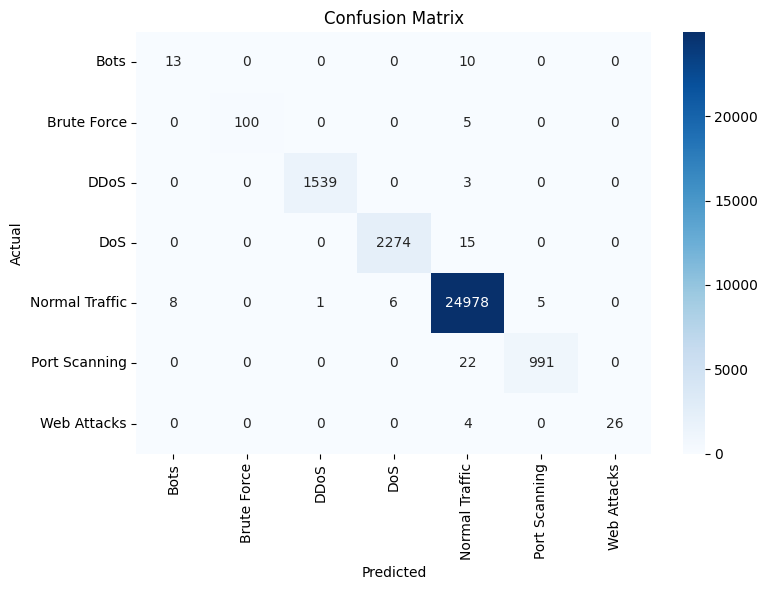

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt


sample_size = 100000  #adjusted because of ram shortage
data_sample = data.sample(n=sample_size, random_state=42)


X = data_sample[numeric_features]
y = data_sample['Attack Type']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


rf = RandomForestClassifier(random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)


y_pred = rf.predict(X_test)


print("Classification Report:\n")
print(classification_report(y_test, y_pred))


cm = confusion_matrix(y_test, y_pred)
labels = rf.classes_

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


In [ ]:
data['Attack Type'].value_counts()

,count
Attack Type,
Normal Traffic,2095057
DoS,193745
DDoS,128014
Port Scanning,90694
Brute Force,9150
Web Attacks,2143
Bots,1948


In [ ]:
from sklearn.utils import resample

balanced_data = data.copy()


normal_df = balanced_data[balanced_data['Attack Type'] == 'Normal Traffic']
attack_df = balanced_data[balanced_data['Attack Type'] != 'Normal Traffic']

print("Original Normal:", len(normal_df))
print("Original Attacks:", len(attack_df))
print("Original Total:", len(balanced_data))


target_normal_size = 375000

normal_downsampled = resample(
    normal_df,
    replace=False,
    n_samples=target_normal_size,
    random_state=42
)


balanced_data = pd.concat([normal_downsampled, attack_df])


balanced_data = balanced_data.sample(frac=1, random_state=42).reset_index(drop=True)
print("\nNew Total Size:", len(balanced_data))
print("\nNew Class Distribution:\n")
print(balanced_data['Attack Type'].value_counts())

Original Normal: 2095057
Original Attacks: 425694
Original Total: 2520751

New Total Size: 800694

New Class Distribution:

Attack Type
Normal Traffic    375000
DoS               193745
DDoS              128014
Port Scanning      90694
Brute Force         9150
Web Attacks         2143
Bots                1948
Name: count, dtype: int64


In [ ]:
from sklearn.utils import resample

balanced_data = data.copy()


normal_df = balanced_data[balanced_data['Attack Type'] == 'Normal Traffic']
attack_df = balanced_data[balanced_data['Attack Type'] != 'Normal Traffic']

print("Original Normal:", len(normal_df))
print("Original Attacks:", len(attack_df))
print("Original Total:", len(balanced_data))


target_normal_size = 375000

normal_downsampled = resample(
    normal_df,
    replace=False,
    n_samples=target_normal_size,
    random_state=42
)


balanced_data = pd.concat([normal_downsampled, attack_df])


balanced_data = balanced_data.sample(frac=1, random_state=42).reset_index(drop=True)
print("\nNew Total Size:", len(balanced_data))
print("\nNew Class Distribution:\n")
print(balanced_data['Attack Type'].value_counts())

Original Normal: 2095057
Original Attacks: 425694
Original Total: 2520751

New Total Size: 800694

New Class Distribution:

Attack Type
Normal Traffic    375000
DoS               193745
DDoS              128014
Port Scanning      90694
Brute Force         9150
Web Attacks         2143
Bots                1948
Name: count, dtype: int64


In [ ]:
balanced_data.to_csv('cicids2017_balanced_800k.csv', index=False)


In [ ]:
data = pd.read_csv('cicids2017_balanced_800k.csv')

X = data[numeric_features]
y = data['Attack Type']

In [ ]:
balanced_data['Attack Type'].value_counts()

,count
Attack Type,
Normal Traffic,375000
DoS,193745
DDoS,128014
Port Scanning,90694
Brute Force,9150
Web Attacks,2143
Bots,1948


In [ ]:
X = balanced_data[numeric_features]
y = balanced_data['Attack Type']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
rf = RandomForestClassifier(
    n_estimators=30,
    max_depth=10,
    min_samples_leaf=20,
    min_samples_split=30,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred))
from sklearn.metrics import accuracy_score
print("Real Accuracy:", accuracy_score(y_test, y_pred))

                precision    recall  f1-score   support

          Bots       0.89      0.61      0.72       585
   Brute Force       1.00      0.96      0.98      2745
          DDoS       1.00      1.00      1.00     38404
           DoS       1.00      0.99      0.99     58124
Normal Traffic       0.99      1.00      0.99    112500
 Port Scanning       1.00      1.00      1.00     27208
   Web Attacks       0.99      0.82      0.90       643

      accuracy                           0.99    240209
     macro avg       0.98      0.91      0.94    240209
  weighted avg       0.99      0.99      0.99    240209

Real Accuracy: 0.9939594269989884
